# **Project HR**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

In [ ]:
from google.colab import files
uplod_file=files.upload()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv


In [ ]:
df=pd.read_csv("HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
num_col = list(df.describe().columns)
col_categorical = list(set(df.columns).difference(num_col))
remove_list = ['EmployeeCount','EmployeeNumber','StandardHours','Attrition_num']
attrition_to_num = {'Yes':1,'No':0}
df['Attrition_num'] = df['Attrition'].map(attrition_to_num)
col_numerical = [e for e in num_col if e not in remove_list]
col_categorical.remove('Attrition')
df_cat = pd.get_dummies(df[col_categorical])
x = pd.concat([df[col_numerical], df_cat], axis=1)
y = df['Attrition_num']

# **Decision Tree**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(random_state=42)
clf.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_predict,cross_val_score
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [ ]:
def print_score(clf,x_train,x_test,y_train,y_test,train=True):
  if train:
    print('Train Result:\n')
    print("acccuracy score:{0:.4f}\n".format(accuracy_score(y_train,clf.predict(x_train))))
    print("classification report:\n {}\n".format(classification_report(y_train,clf.predict(x_train))))
    print("confusion_matrix:\n{}\n".format(confusion_matrix(y_train,clf.predict(x_train))))
    res=cross_val_score(clf,x_train,y_train,cv=10,scoring='accuracy')
    print("Average Accuracy:\t {0:.4f}".format(np.mean(res)))
    print("Accuracy SD: \t \t{0:.4f}".format(np.std(res)))
  elif train==False:
    '''
    test performance
    '''
    print('Test Result:\n')
    print("acccuracy score:{0:.4f}\n".format(accuracy_score(y_test,clf.predict(x_test))))
    print("classification report:\n {}\n".format(classification_report(y_test,clf.predict(x_test))))
    print("confusion_matrix:\n{}\n".format(confusion_matrix(y_test,clf.predict(x_test))))



In [ ]:
print_score(clf,x_train,x_test,y_train,y_test,train=True)
print_score(clf,x_train,x_test,y_train,y_test,train=False)


Train Result:

acccuracy score:1.0000

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       927
           1       1.00      1.00      1.00       175

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


confusion_matrix:
[[927   0]
 [  0 175]]

Average Accuracy:	 0.7858
Accuracy SD: 	 	0.0302
Test Result:

acccuracy score:0.7609

classification report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.85       306
           1       0.32      0.37      0.34        62

    accuracy                           0.76       368
   macro avg       0.59      0.61      0.60       368
weighted avg       0.78      0.76      0.77       368


confusion_matrix:
[[257  49]
 [ 39  23]]



# **bagging**

In [ ]:
from sklearn.ensemble import BaggingClassifier
bag_clf=BaggingClassifier(estimator=clf,n_estimators=100,
                          bootstrap=True,n_jobs=-1,random_state=42)
bag_clf.fit(x_train,y_train.ravel())

/tmp/ipython-input-3256107179.py:4: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  bag_clf.fit(x_train,y_train.ravel())


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, n_jobs=-1, random_state=42)

In [ ]:
print_score(bag_clf,x_train,x_test,y_train,y_test,train=True)
print_score(bag_clf,x_train,x_test,y_train,y_test,train=False)

Train Result:

acccuracy score:1.0000

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       927
           1       1.00      1.00      1.00       175

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


confusion_matrix:
[[927   0]
 [  0 175]]

Average Accuracy:	 0.8576
Accuracy SD: 	 	0.0132
Test Result:

acccuracy score:0.8587

classification report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92       306
           1       0.73      0.26      0.38        62

    accuracy                           0.86       368
   macro avg       0.80      0.62      0.65       368
weighted avg       0.84      0.86      0.83       368


confusion_matrix:
[[300   6]
 [ 46  16]]



# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_clf=RandomForestClassifier(n_estimators=100)

In [ ]:
rf_clf.fit(x_train,y_train.ravel())

/tmp/ipython-input-2570993573.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  rf_clf.fit(x_train,y_train.ravel())


RandomForestClassifier()

In [ ]:
print_score(rf_clf,x_train,x_test,y_train,y_test,train=True)
print_score(rf_clf,x_train,x_test,y_train,y_test,train=False)

Train Result:

acccuracy score:1.0000

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       927
           1       1.00      1.00      1.00       175

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


confusion_matrix:
[[927   0]
 [  0 175]]

Average Accuracy:	 0.8575
Accuracy SD: 	 	0.0110
Test Result:

acccuracy score:0.8641

classification report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92       306
           1       0.93      0.21      0.34        62

    accuracy                           0.86       368
   macro avg       0.90      0.60      0.63       368
weighted avg       0.87      0.86      0.83       368


confusion_matrix:
[[305   1]
 [ 49  13]]



In [ ]:
import seaborn as sns

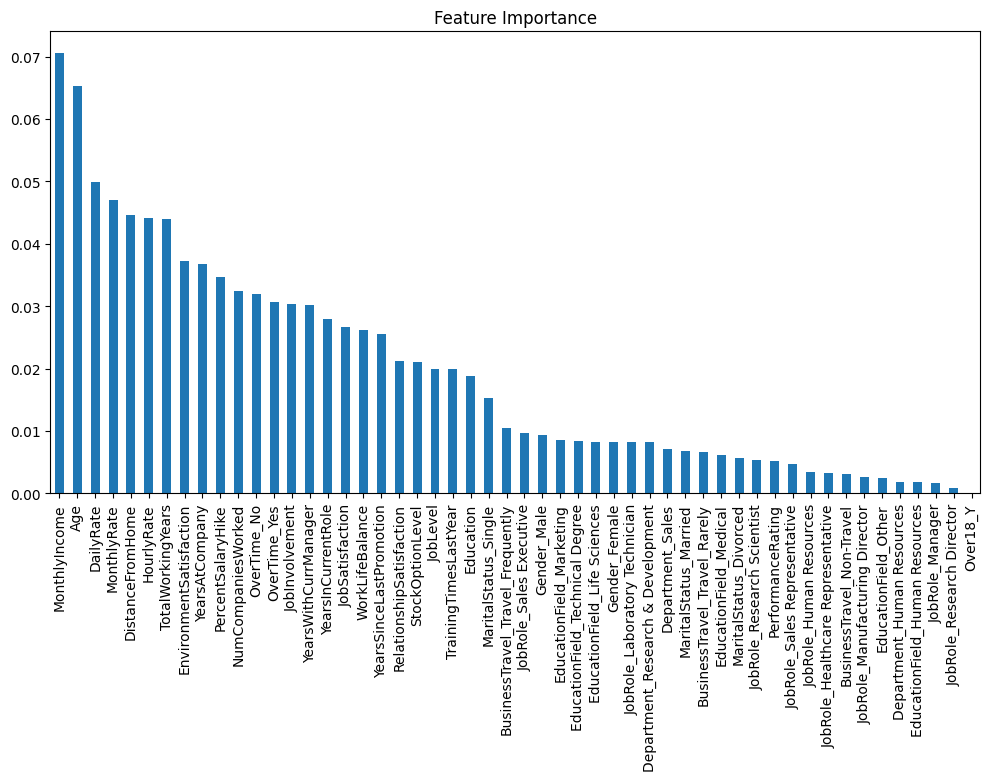

In [ ]:
pd.Series(rf_clf.feature_importances_,
          index=x_train.columns).sort_values(ascending=False).plot(kind='bar',figsize=(12,6),title='Feature Importance');

# **AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada_clf=AdaBoostClassifier()

In [ ]:
ada_clf.fit(x_train,y_train.ravel())

/tmp/ipython-input-2302715909.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  ada_clf.fit(x_train,y_train.ravel())


AdaBoostClassifier()

In [ ]:
print_score(ada_clf,x_train,x_test,y_train,y_test,train=True)
print_score(ada_clf,x_train,x_test,y_train,y_test,train=False)

Train Result:

acccuracy score:0.8775

classification report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93       927
           1       0.86      0.27      0.42       175

    accuracy                           0.88      1102
   macro avg       0.87      0.63      0.67      1102
weighted avg       0.88      0.88      0.85      1102


confusion_matrix:
[[919   8]
 [127  48]]

Average Accuracy:	 0.8657
Accuracy SD: 	 	0.0183
Test Result:

acccuracy score:0.8750

classification report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93       306
           1       0.94      0.27      0.42        62

    accuracy                           0.88       368
   macro avg       0.91      0.64      0.68       368
weighted avg       0.88      0.88      0.84       368


confusion_matrix:
[[305   1]
 [ 45  17]]



# **AdaBoost+RandomForest**

In [ ]:
Ada_clf=AdaBoostClassifier(RandomForestClassifier(n_estimators=100),n_estimators=100)
Ada_clf.fit(x_train,y_train.ravel())

/tmp/ipython-input-981326575.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Ada_clf.fit(x_train,y_train.ravel())


AdaBoostClassifier(estimator=RandomForestClassifier(), n_estimators=100)

In [ ]:
print_score(Ada_clf,x_train,x_test,y_train,y_test,train=True)
print_score(Ada_clf,x_train,x_test,y_train,y_test,train=False)

Train Result:

acccuracy score:1.0000

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       927
           1       1.00      1.00      1.00       175

    accuracy                           1.00      1102
   macro avg       1.00      1.00      1.00      1102
weighted avg       1.00      1.00      1.00      1102


confusion_matrix:
[[927   0]
 [  0 175]]

Average Accuracy:	 0.8566
Accuracy SD: 	 	0.0096
Test Result:

acccuracy score:0.8587

classification report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       306
           1       1.00      0.16      0.28        62

    accuracy                           0.86       368
   macro avg       0.93      0.58      0.60       368
weighted avg       0.88      0.86      0.81       368


confusion_matrix:
[[306   0]
 [ 52  10]]



# **Gradient Boosting Classifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gbc_clf=GradientBoostingClassifier(n_estimators=100)
gbc_clf.fit(x_train,y_train.ravel())

/tmp/ipython-input-1846959113.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  gbc_clf.fit(x_train,y_train.ravel())


GradientBoostingClassifier()

In [ ]:
print_score(gbc_clf,x_train,x_test,y_train,y_test,train=True)
print_score(gbc_clf,x_train,x_test,y_train,y_test,train=False)

Train Result:

acccuracy score:0.9619

classification report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       927
           1       1.00      0.76      0.86       175

    accuracy                           0.96      1102
   macro avg       0.98      0.88      0.92      1102
weighted avg       0.96      0.96      0.96      1102


confusion_matrix:
[[927   0]
 [ 42 133]]

Average Accuracy:	 0.8775
Accuracy SD: 	 	0.0162
Test Result:

acccuracy score:0.8587

classification report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92       306
           1       0.75      0.24      0.37        62

    accuracy                           0.86       368
   macro avg       0.81      0.61      0.64       368
weighted avg       0.85      0.86      0.83       368


confusion_matrix:
[[301   5]
 [ 47  15]]

